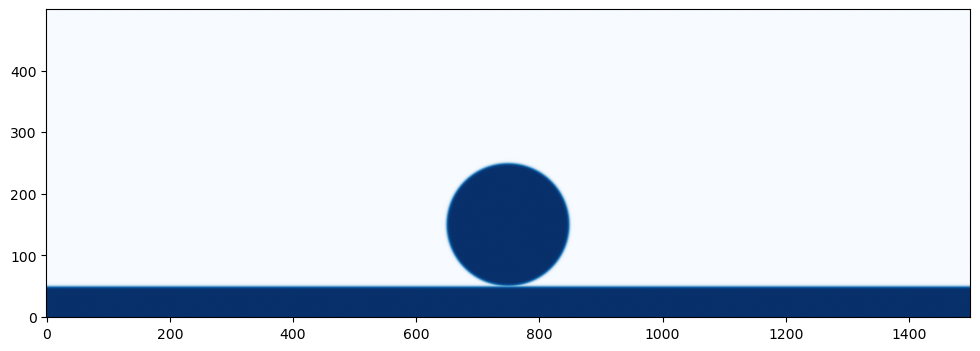

In [24]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

Nx = 1500
Ny = 500
W = 5.0
R = 100.0
Hw = 50.0
U = 0.03

x = np.arange(Nx) + 0.5
y = np.arange(Ny) + 0.5
y_coord, x_coord = np.meshgrid(y, x) 

phi_film = 0.5 + 0.5 * np.tanh(2.0 * (Hw - y_coord) / W)
dist = np.sqrt((x_coord - 0.5 * Nx)**2 + (y_coord - (R + Hw))**2)
phi_drop = 0.5 + 0.5 * np.tanh(2.0 * (R - dist) / W)
phi = np.maximum(phi_film, phi_drop).astype(np.float64)

ux = np.zeros((Nx, Ny), dtype=np.float64)
uy = np.zeros((Nx, Ny), dtype=np.float64)

mask_drop = dist <= R
uy[mask_drop] = -U

plt.figure(figsize=(12, 4))
plt.imshow(phi.T, origin='lower', cmap='Blues')
plt.show()

with h5py.File('phi.h5', 'w') as f:
    f.create_dataset('phi', data=phi)

with h5py.File('ux.h5', 'w') as f:
    f.create_dataset('ux', data=ux)

with h5py.File('uy.h5', 'w') as f:
    f.create_dataset('uy', data=uy)


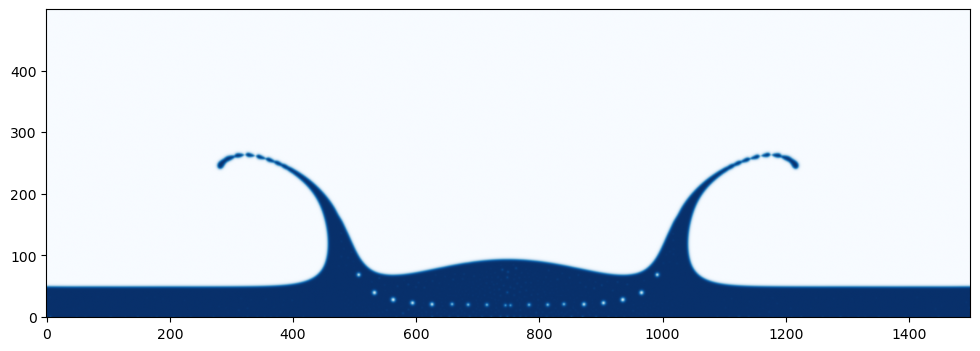

In [22]:
with h5py.File('droplet_impact.h5', 'r') as hf:
    keys = list(hf.keys())
    c_key_idx = np.sort([int(k.split('.')[-1]) for k in keys if 'rho' in k])
    plot_var = hf['rho.'+str(c_key_idx[-1])][()].T

plt.figure(figsize=(12, 4))
plt.imshow(plot_var, origin='lower', cmap='Blues')
plt.show()